# Human gastric cancer preprocess

Prepare the data for training.


## Settings


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

scanvi_train_kwargs = {"accelerator": "gpu", "devices": 1, "enable_progress_bar": False}
from pathlib import Path
import yaml

DATASET = 'GP1'
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "human_gastric_cancer"
REPO_ROOT = EXPERIMENT_DIR.parents[1]
import sys

CONFIG = yaml.safe_load(
    (EXPERIMENT_DIR / "config.yaml").read_text(encoding="utf-8")
)

def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else (EXPERIMENT_DIR / path).resolve()

DATA_ROOT = experiment_path(CONFIG["data_root"])
RUN_ROOT = experiment_path(CONFIG["run_root"])
CHECKPOINT_ROOT = experiment_path(CONFIG["checkpoint_root"])
SCANVI_DIR = experiment_path(CONFIG["scanvi_dir"])
SCANVI_ADATA = SCANVI_DIR / "adata.h5ad"
LR_PAIRS = experiment_path(CONFIG["lr_pairs_path"])
TRANSITION_PRIOR = experiment_path(CONFIG["transition_prior_path"]) if "transition_prior_path" in CONFIG else None
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)


from _shared.preprocess_plots import annotation_palette, sample_panels, alignment_overlay, embedding_panels


In [2]:
from pathlib import Path
import scanpy as sc 
import numpy as np
import pandas as pd


def read_visium(sample_dir: Path):
    import scanpy as sc

    if hasattr(sc, "read_visium"):
        count_file = "filtered_feature_bc_matrix.h5" if (sample_dir / "filtered_feature_bc_matrix.h5").exists() else None
        if count_file is not None:
            adata = sc.read_visium(path=str(sample_dir), count_file=count_file, load_images=True)
        else:
            adata = sc.read_visium(path=str(sample_dir), load_images=True)
        return adata

    try:
        import squidpy as sq
    except Exception as e:
        raise ImportError("Neither scanpy.read_visium nor squidpy.read.visium is available.") from e

    count_file = "filtered_feature_bc_matrix.h5" if (sample_dir / "filtered_feature_bc_matrix.h5").exists() else None
    if count_file is not None:
        return sq.read.visium(path=str(sample_dir), counts_file=count_file)
    return sq.read.visium(path=str(sample_dir))


def add_metadata_from_csv(
    adata,
    metadata_csv: Path,
    barcode_col="Cell",
):
    meta = pd.read_csv(metadata_csv)

    if barcode_col not in meta.columns:
        raise ValueError(f"{metadata_csv} must contain column: {barcode_col}")

    meta = meta.copy()
    meta[barcode_col] = meta[barcode_col].astype(str)

    # , barcode  join 
    if meta[barcode_col].duplicated().any():
        dup_n = int(meta[barcode_col].duplicated().sum())
        print(f"Warning: found {dup_n} duplicated barcodes in metadata; keep first occurrence.")
        meta = meta.drop_duplicates(subset=[barcode_col], keep="first")

    meta = meta.set_index(barcode_col)

    adata = adata.copy()
    adata.obs.index = adata.obs.index.astype(str)

    # : adata  barcode  metadata
    adata.obs = adata.obs.join(meta, how="left")

    matched = int(adata.obs.index.isin(meta.index).sum())
    print(f"Matched metadata: {matched}/{adata.n_obs}")

    return adata


def run_visium_build_h5ad(
    sample_dir,
    processed_dir,
    metadata_csv=None,
    out_name=None,
    barcode_col="Cell",
):
    sample_dir = Path(sample_dir).resolve()
    processed_dir = Path(processed_dir).resolve()

    print(f"Reading Visium data from: {sample_dir}")
    adata = read_visium(sample_dir)
    print(adata)

    #  counts
    adata.layers["counts"] = adata.X.copy()
    adata.var_names_make_unique()

    if metadata_csv is not None:
        metadata_csv = Path(metadata_csv).resolve()
        if not metadata_csv.exists():
            raise FileNotFoundError(f"Metadata CSV not found: {metadata_csv}")

        print(f"Reading metadata from: {metadata_csv}")
        adata = add_metadata_from_csv(
            adata,
            metadata_csv=metadata_csv,
            barcode_col=barcode_col,
        )

    out_h5ad = None
    if out_name is not None:
        out_h5ad = processed_dir / out_name
        adata.write_h5ad(out_h5ad)
        print(f"Saved: {out_h5ad}")
    print("Done.")

    return adata, out_h5ad


## Prepare data


In [3]:
adata, _ = run_visium_build_h5ad(
    sample_dir=DATA_ROOT / "raw",
    metadata_csv=DATA_ROOT / "P1_cluster.csv",
    processed_dir=DATA_ROOT,
    out_name=None,
    barcode_col="Cell",
)


Reading Visium data from: /home/zhouyj/project/data/GP1/GP1


/tmp/ipykernel_2683563/2904183342.py:13: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=str(sample_dir), count_file=count_file, load_images=True)


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
Reading metadata from: /home/zhouyj/project/data/GP1/GP1/P1_cluster.csv
Matched metadata: 2174/2174
Done.


In [4]:
adata


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'

In [5]:
adata.obs["cluster"] = adata.obs["cluster"].astype(str).astype("category")


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


spatial libraries: ['1-KZ1']


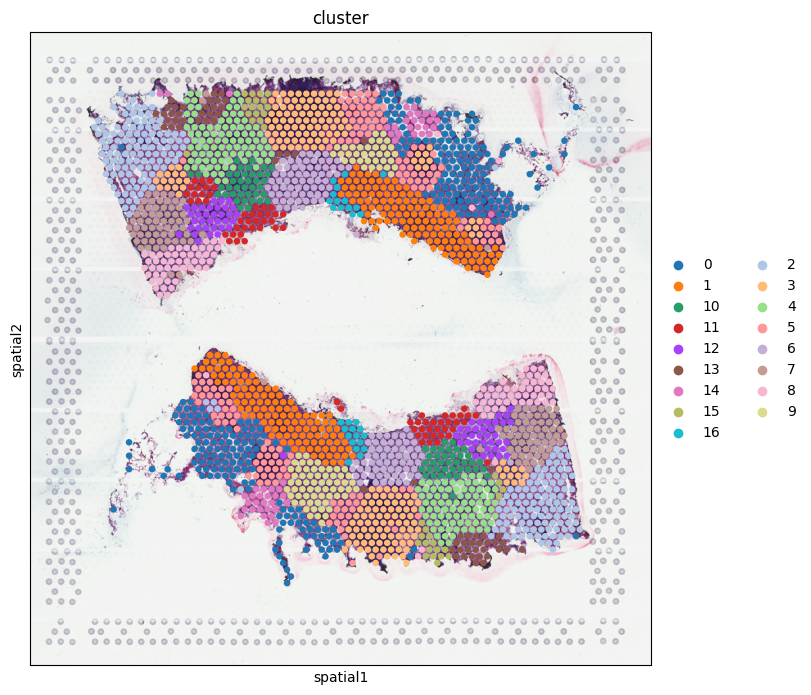

In [6]:
import matplotlib.pyplot as plt
import squidpy as sq

#  library_id
print("spatial libraries:", list(adata.uns["spatial"].keys()))

lib = list(adata.uns["spatial"].keys())[0]

# +spot
sq.pl.spatial_scatter(
    adata,
    library_id=lib,
    color="cluster",   #  cluster,
    img=True,
    size=1.3,
    legend_loc="right margin",
    figsize=(8, 8),
)
plt.show()


In [7]:
adata.obs["cluster"] = adata.obs["cluster"].astype(str)
adata.obs["cluster"] = adata.obs["cluster"].replace({"16": "1"})
adata.obs["cluster"] = adata.obs["cluster"].astype("category")


In [8]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)


In [9]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)


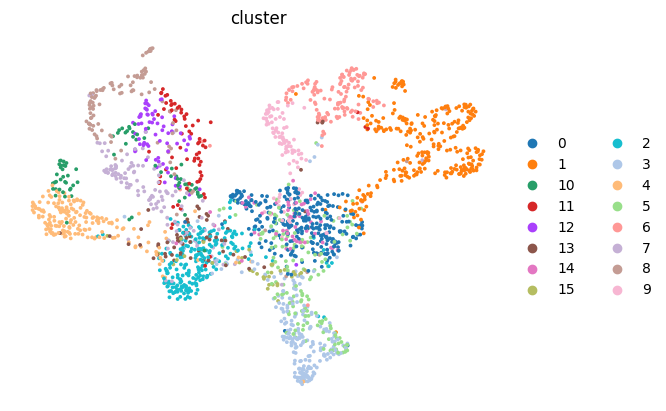

In [10]:
sc.pl.umap(
    adata,
    color="cluster",
    size=30,
    frameon=False
)


In [11]:
adata


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [12]:
import scvi, os


## Train scanVI


In [13]:
scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    labels_key="cluster",
    unlabeled_category="Unknown",   
    batch_key=None
)
model = scvi.model.SCANVI(adata)
model.train(**scanvi_train_kwargs)
model_dir = SCANVI_DIR


INFO     Training for 400 epochs.                                                                                  


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


/home/zhouyj/.conda/envs/3dslice/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=207` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=400` reached.


In [14]:
model_dir = SCANVI_DIR


In [15]:
SCVI_LATENT_KEY = CONFIG.get("latent_key", "X_scanVI")
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY].shape


(2174, 10)

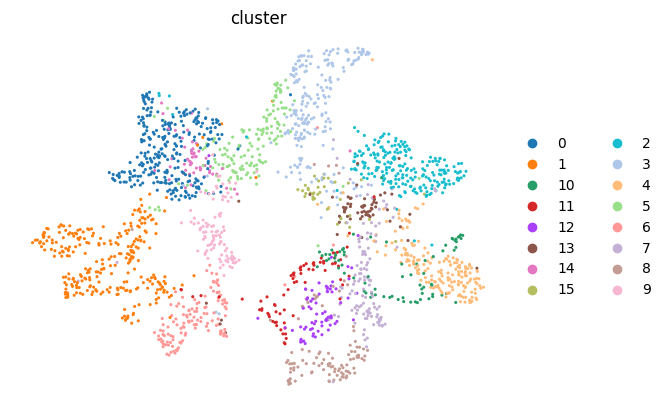

In [16]:
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cluster"],frameon=False,size = 20,)


In [17]:
adata


AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## Spatial alignment


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans


def split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",
    normal_clusters=("7", "8", "12"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"adata.obs  {cluster_col}")

    if "spatial" not in adata.obsm:
        raise KeyError("adata.obsm  'spatial'")

    ad = adata.copy()

    # 1) cluster , 16 -> 1
    ad.obs[cluster_col] = ad.obs[cluster_col].astype(str)
    if merge_map is not None:
        ad.obs[cluster_col] = ad.obs[cluster_col].replace(merge_map)

    # 2)  cluster
    keep_clusters = set(map(str, normal_clusters)) | set(map(str, cancer_clusters))
    ad = ad[ad.obs[cluster_col].isin(keep_clusters)].copy()

    # 3)  normal / cancer
    normal_clusters = set(map(str, normal_clusters))
    cancer_clusters = set(map(str, cancer_clusters))

    ad.obs["state"] = np.where(
        ad.obs[cluster_col].isin(normal_clusters),
        "normal",
        "cancer"
    )
    ad.obs["state"] = pd.Categorical(ad.obs["state"], categories=["normal", "cancer"])

    # 4)  spatial  y  upper / lower
    xy = np.asarray(ad.obsm["spatial"])
    y = xy[:, 1].reshape(-1, 1)

    km = KMeans(n_clusters=2, random_state=0, n_init=10)
    grp = km.fit_predict(y)

    means = {g: float(y[grp == g].mean()) for g in np.unique(grp)}
    upper_grp = min(means, key=means.get)   #  y 

    ad.obs["tissue_side"] = np.where(grp == upper_grp, "upper", "lower")
    ad.obs["tissue_side"] = pd.Categorical(ad.obs["tissue_side"], categories=["upper", "lower"])

    # 5)  adata
    adata_upper_normal = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "normal")].copy()
    adata_lower_normal = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "normal")].copy()
    adata_upper_cancer = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "cancer")].copy()
    adata_lower_cancer = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "cancer")].copy()

    # 
    ad.obs[cluster_col] = pd.Categorical(
        ad.obs[cluster_col],
        categories=sorted(ad.obs[cluster_col].astype(str).unique(), key=lambda x: int(x)),
        ordered=True
    )

    return {
        "adata_sub": ad,
        "adata_upper_normal": adata_upper_normal,
        "adata_lower_normal": adata_lower_normal,
        "adata_upper_cancer": adata_upper_cancer,
        "adata_lower_cancer": adata_lower_cancer,
    }


In [19]:
res = split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",   #  cluster,
    normal_clusters=("7", "8", "12"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
)

adata_sub = res["adata_sub"]
adata_upper_normal = res["adata_upper_normal"]
adata_lower_normal = res["adata_lower_normal"]
adata_upper_cancer = res["adata_upper_cancer"]
adata_lower_cancer = res["adata_lower_cancer"]

print(adata_sub)
print("upper_normal :", adata_upper_normal.shape)
print("lower_normal :", adata_lower_normal.shape)
print("upper_cancer :", adata_upper_cancer.shape)
print("lower_cancer :", adata_lower_cancer.shape)


AnnData object with n_obs × n_vars = 812 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'cluster_colors', 'log1p', 'pca', 'neighbors', 'umap', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
upper_normal : (151, 36601)
lower_normal : (151, 36601)
upper_cancer : (247, 36601)
lower_cancer : (263, 36601)


In [20]:
adata_upper_normal = res["adata_upper_normal"]
adata_upper_cancer = res["adata_upper_cancer"]


/tmp/ipykernel_2683563/2763538918.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)


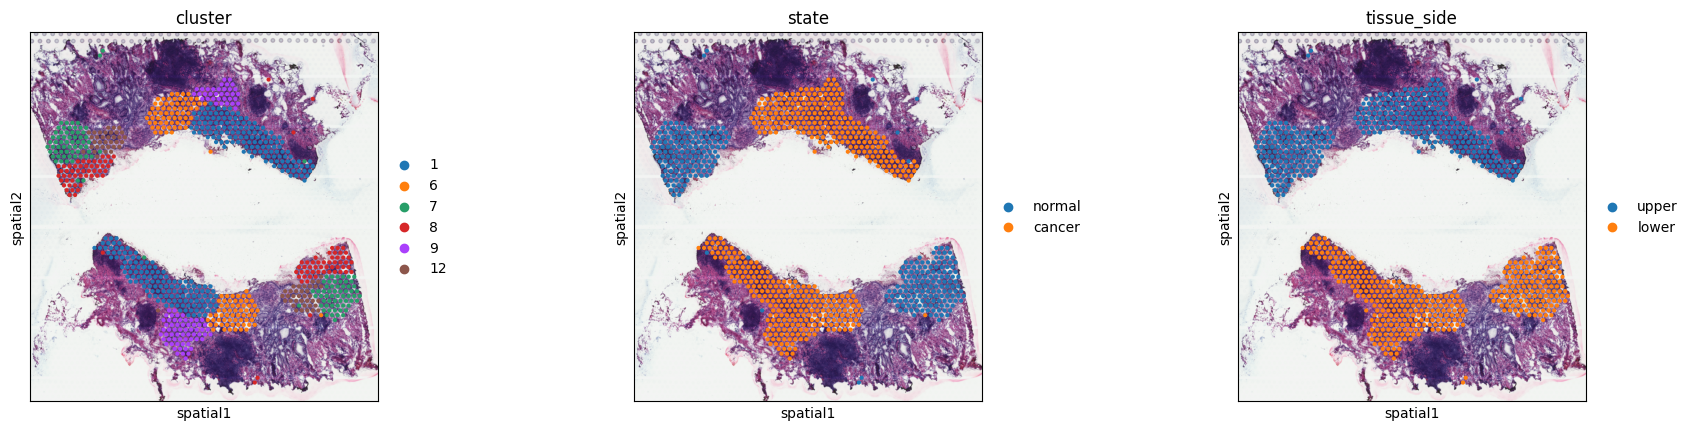

/tmp/ipykernel_2683563/2763538918.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_normal, color=["cluster"], spot_size=150)


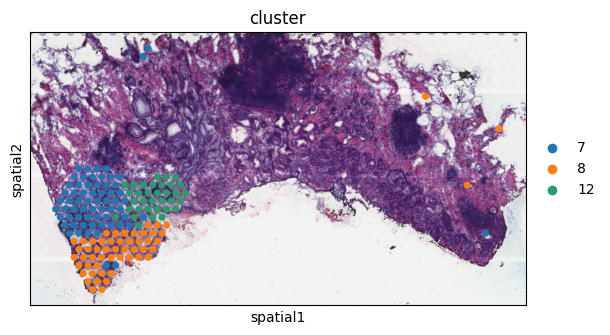

/tmp/ipykernel_2683563/2763538918.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_cancer, color=["cluster"], spot_size=150)


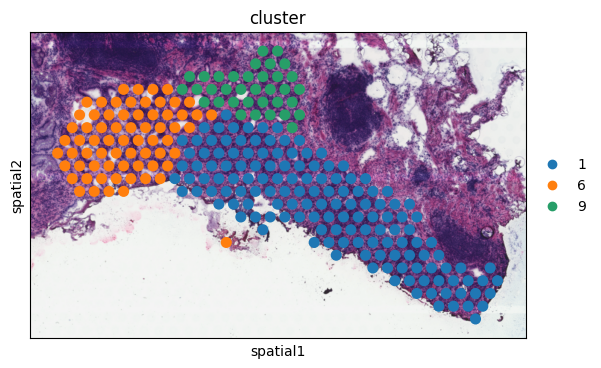

In [21]:
import scanpy as sc

sc.pl.spatial(adata_sub, color=["cluster", "state", "tissue_side"], spot_size=150)
sc.pl.spatial(adata_upper_normal, color=["cluster"], spot_size=150)
sc.pl.spatial(adata_upper_cancer, color=["cluster"], spot_size=150)


In [22]:
import numpy as np
from sklearn.neighbors import NearestNeighbors, radius_neighbors_graph
from scipy.sparse.csgraph import connected_components


def keep_largest_spatial_component(
    adata,
    spatial_key="spatial",
    radius=None,
    radius_scale=1.35,
    return_mask=False,
    verbose=True,
):
    """
    。
    radius ,。
    """
    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm  {spatial_key}")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm['{spatial_key}']  n x 2")

    if adata.n_obs <= 1:
        return (adata.copy(), np.ones(adata.n_obs, dtype=bool)) if return_mask else adata.copy()

    # :
    if radius is None:
        nn = NearestNeighbors(n_neighbors=2)
        nn.fit(xy)
        dists, _ = nn.kneighbors(xy)
        nn1 = dists[:, 1]
        base = float(np.median(nn1[np.isfinite(nn1)]))
        radius = radius_scale * base

    # :
    G = radius_neighbors_graph(xy, radius=radius, mode="connectivity", include_self=False)
    n_comp, labels = connected_components(G, directed=False)

    comp_sizes = np.bincount(labels)
    largest_label = np.argmax(comp_sizes)
    keep_mask = (labels == largest_label)

    if verbose:
        print(f"radius = {radius:.3f}")
        print(f"n_components = {n_comp}")
        print(f"largest component size = {comp_sizes[largest_label]}/{adata.n_obs}")
        print(f"dropped = {(~keep_mask).sum()}")

    out = adata[keep_mask].copy()
    return (out, keep_mask) if return_mask else out


In [23]:
adata_upper_normal_clean = keep_largest_spatial_component(adata_upper_normal)
adata_upper_cancer_clean = keep_largest_spatial_component(adata_upper_cancer)


radius = 268.650
n_components = 6
largest component size = 145/151
dropped = 6
radius = 268.650
n_components = 2
largest component size = 246/247
dropped = 1


/tmp/ipykernel_2683563/2368206013.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)


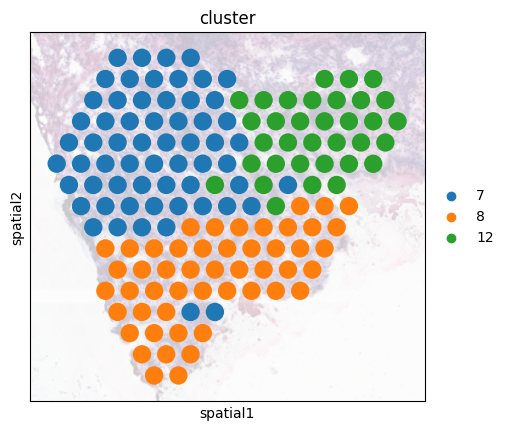

/tmp/ipykernel_2683563/2368206013.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_upper_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)


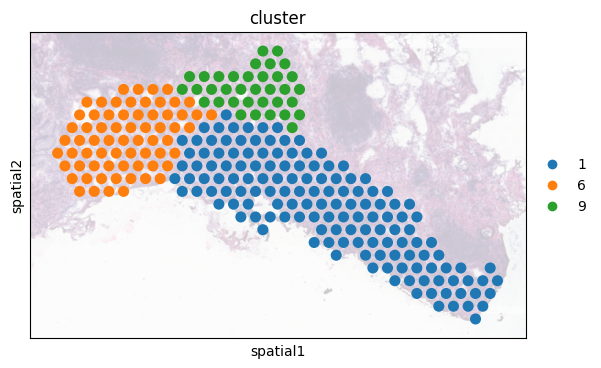

In [24]:
sc.pl.spatial(adata_upper_normal_clean, color="cluster", spot_size=150, alpha_img=0.25)
sc.pl.spatial(adata_upper_cancer_clean, color="cluster", spot_size=150, alpha_img=0.25)


In [25]:
import sys

from stvirtual.models import uot_alignment_trans as alt


In [26]:
import anndata as ad

adata_upper_normal_clean = adata_upper_normal_clean.copy()
adata_upper_cancer_clean = adata_upper_cancer_clean.copy()

adata_upper_normal_clean.obs["status"] = "normal"
adata_upper_cancer_clean.obs["status"] = "cancer"

adata_upper_normal_clean.obs["status"] = adata_upper_normal_clean.obs["status"].astype("category")
adata_upper_cancer_clean.obs["status"] = adata_upper_cancer_clean.obs["status"].astype("category")

adata_upper_merged = ad.concat(
    {
        "normal": adata_upper_normal_clean,
        "cancer": adata_upper_cancer_clean,
    },
    join="outer",
    label="source",
    index_unique="-",
    merge="same",
)

adata_upper_merged.obs["status"] = adata_upper_merged.obs["status"].astype("category")

print(adata_upper_merged)
print(adata_upper_merged.obs["status"].value_counts())


AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'
status
cancer    246
normal    145
Name: count, dtype: int64


In [27]:
import importlib
importlib.reload(alt)

ad_src = adata_upper_merged[adata_upper_merged.obs["status"] == "normal"].copy()
ad_ref = adata_upper_merged[adata_upper_merged.obs["status"] == "cancer"].copy()

# --- spatial (2D) ---
X_src = np.asarray(ad_src.obsm["spatial"][:, :2], dtype=np.float64)
X_ref = np.asarray(ad_ref.obsm["spatial"][:, :2], dtype=np.float64)

# --- features: UMAP/PCA (must be comparable across slices) ---
F_src = np.asarray(ad_src.obsm["X_pca"], dtype=np.float64)
F_ref = np.asarray(ad_ref.obsm["X_pca"], dtype=np.float64)

# --- optional labels (clone) ---
ann_src = ad_src.obs["cluster"].astype(str).values
ann_ref = ad_ref.obs["cluster"].astype(str).values

# ===== normalize spatial to stabilize rigid fitting (recommended) =====
X_all = np.vstack([X_src, X_ref]).astype(np.float64)
mu = X_all.mean(axis=0, keepdims=True)
sd = X_all.std(axis=0, keepdims=True) + 1e-8

X_src_n = (X_src - mu) / sd
X_ref_n = (X_ref - mu) / sd

import numpy as np

def minmax01_joint(F_src, F_ref, eps=1e-8, q=None):
    """
    Joint min-max scaling to [0,1] per-dimension, using src+ref together.
    q=None -> exact min/max
    q=(0.01,0.99) -> robust quantile min/max (recommended if outliers)
    """
    F_src = np.asarray(F_src, np.float64)
    F_ref = np.asarray(F_ref, np.float64)
    F_all = np.vstack([F_src, F_ref])

    if q is None:
        fmin = F_all.min(axis=0, keepdims=True)
        fmax = F_all.max(axis=0, keepdims=True)
    else:
        lo, hi = q
        fmin = np.quantile(F_all, lo, axis=0, keepdims=True)
        fmax = np.quantile(F_all, hi, axis=0, keepdims=True)

    denom = np.maximum(fmax - fmin, eps)
    Fs = (F_src - fmin) / denom
    Fr = (F_ref - fmin) / denom

    # ,[0,1],clip
    if q is not None:
        Fs = np.clip(Fs, 0.0, 1.0)
        Fr = np.clip(Fr, 0.0, 1.0)

    return Fs, Fr

Z_src = ad_src.obsm["X_pca"]
Z_ref = ad_ref.obsm["X_pca"]

# A: min/max
# F_src, F_ref = minmax01_joint(Z_src, Z_ref, q=None)

# B（）: min/max,
F_src, F_ref = minmax01_joint(Z_src, Z_ref, q=(0.01, 0.99))

# ===== register (run in normalized space, return normalized aligned coords) =====
X_aligned_n, info1 = alt.register_slice_to_ref_by_features(
    X_src_n, X_ref_n,
    F_src, F_ref,
    ann_src=None, ann_ref=None,
    k_feat=6,
    match_mode="soft",
    alpha_xy=1.0,
    beta_feat=1.0,
    tau=0.8,
    verbose=True,
)

# ===== unnormalize back to original spatial scale =====
X_aligned = X_aligned_n * sd + mu

xy_all = np.asarray(adata_upper_merged.obsm["spatial"][:, :2], dtype=float)

adata_upper_merged.obs["cx_aligned"] = xy_all[:, 0]
adata_upper_merged.obs["cy_aligned"] = xy_all[:, 1]

adata_upper_merged.obs.loc[ad_src.obs_names, "cx_aligned"] = X_aligned[:, 0]
adata_upper_merged.obs.loc[ad_src.obs_names, "cy_aligned"] = X_aligned[:, 1]


UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.804, reg=2.22, score=0.804, th=2.32, trial=1]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.6326, reg=4.44, score=0.6326, th=1.84, trial=2]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5499, reg=8.89, score=0.5499, th=1.85, trial=3]

UOT init (feat):   0%|          | 0/18 [00:00<?, ?it/s, best=0.5499, reg=2.22, score=0.804, th=2.32, trial=4] 

...

ICP refine (feat):  55%|█████▌    | 22/40 [00:00<00:00, 108.22it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48]

ICP refine (feat):  95%|█████████▌| 38/40 [00:00<00:00, 128.59it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48]

ICP refine (feat):  95%|█████████▌| 38/40 [00:00<00:00, 128.59it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48]

ICP refine (feat):  95%|█████████▌| 38/40 [00:00<00:00, 128.59it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48]

ICP refine (feat): 100%|██████████| 40/40 [00:00<00:00, 123.27it/s, cls=1, med=0.4665, p90=0.9929, th=3.07, tx=-0.799, ty=-0.48]

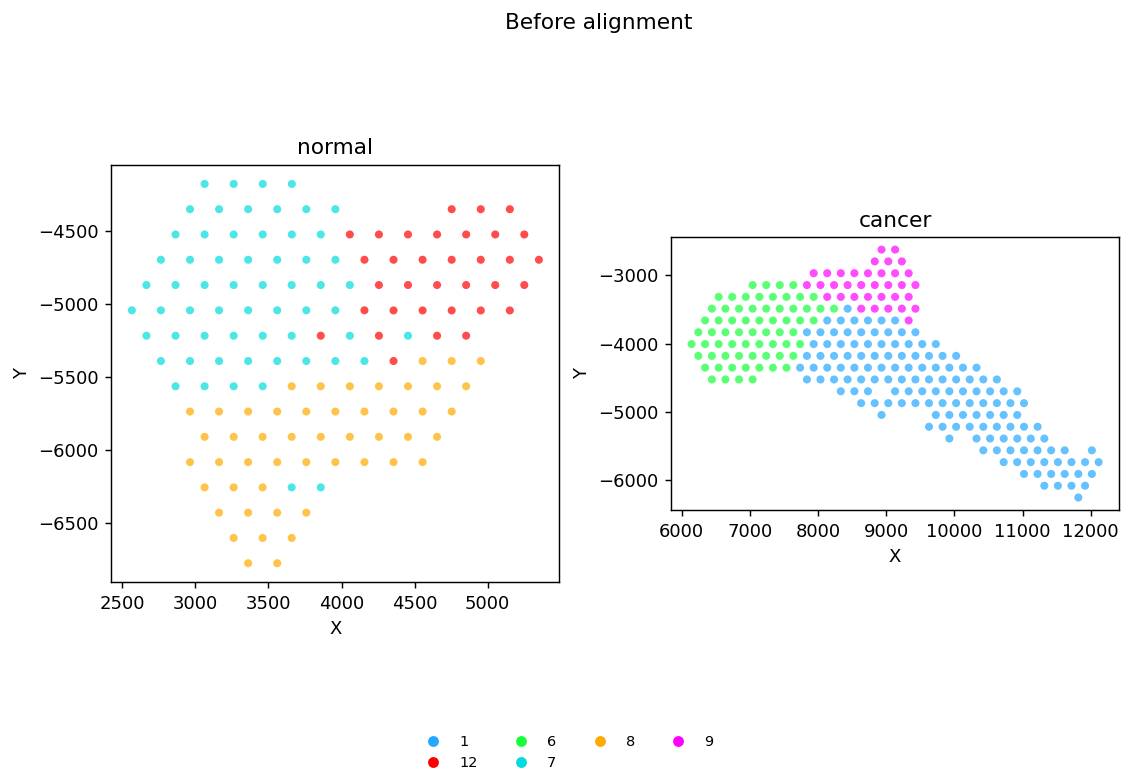

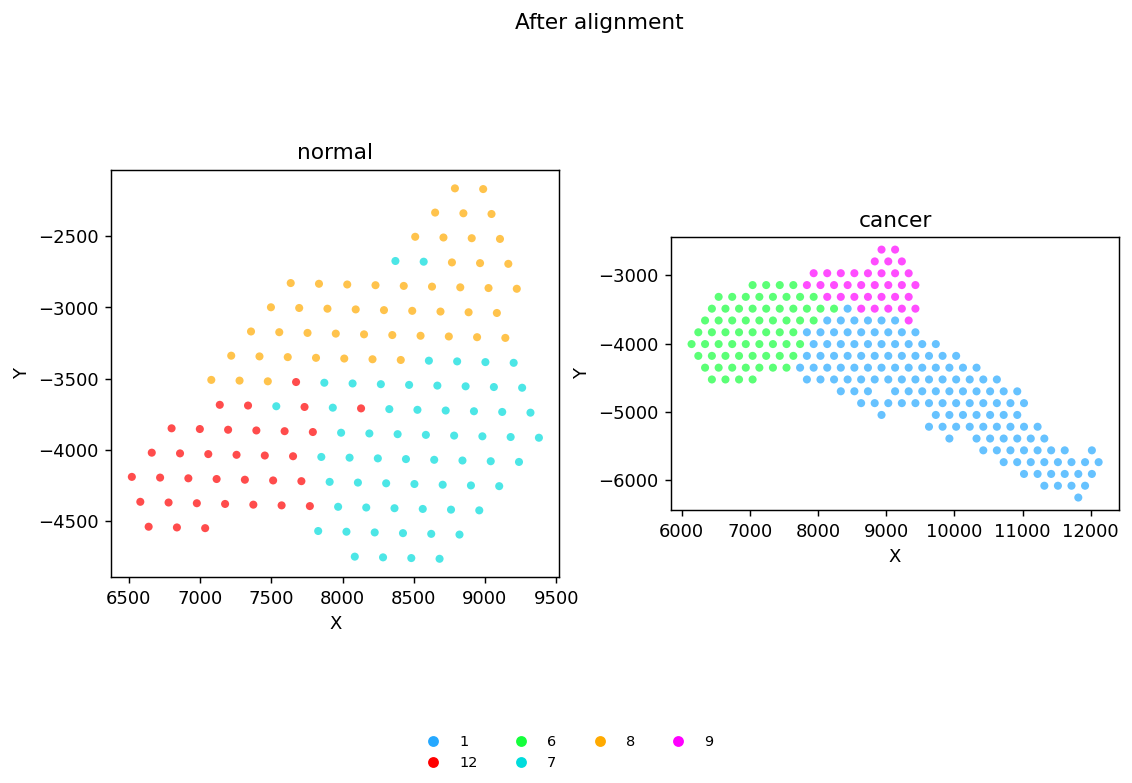

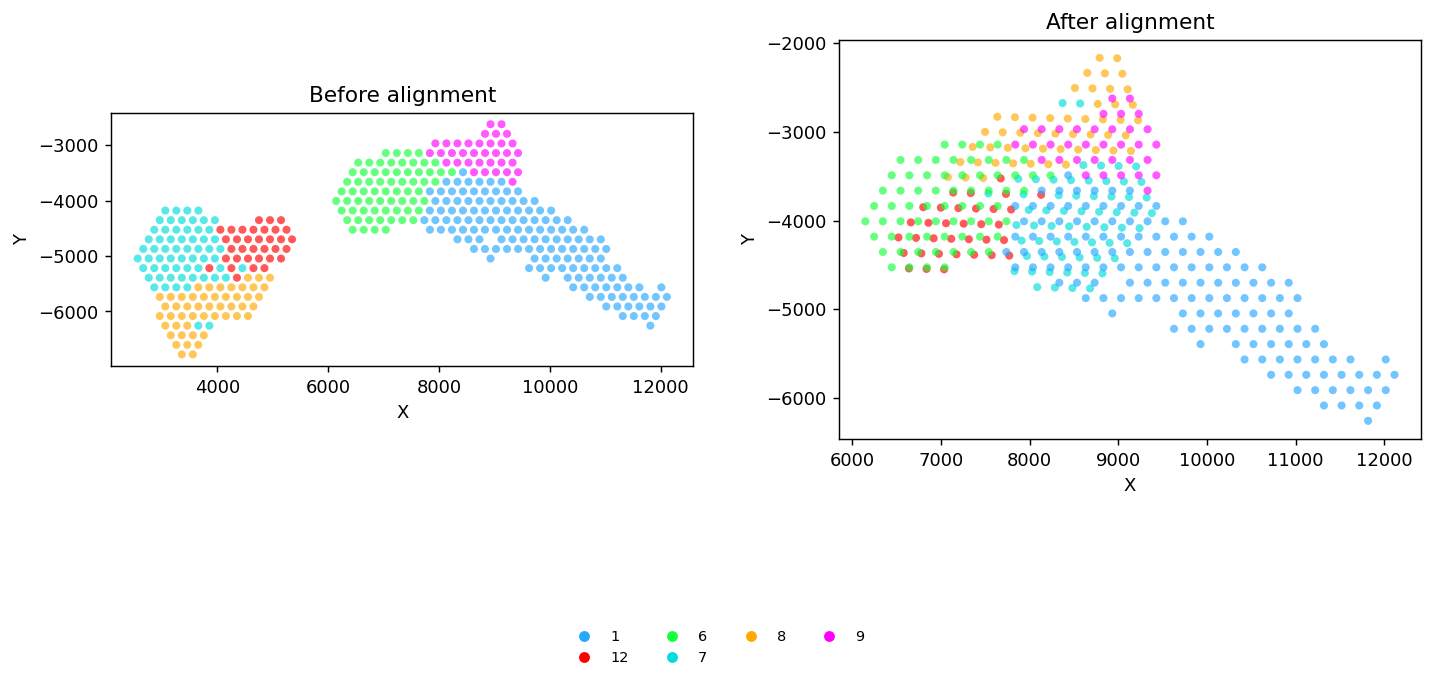

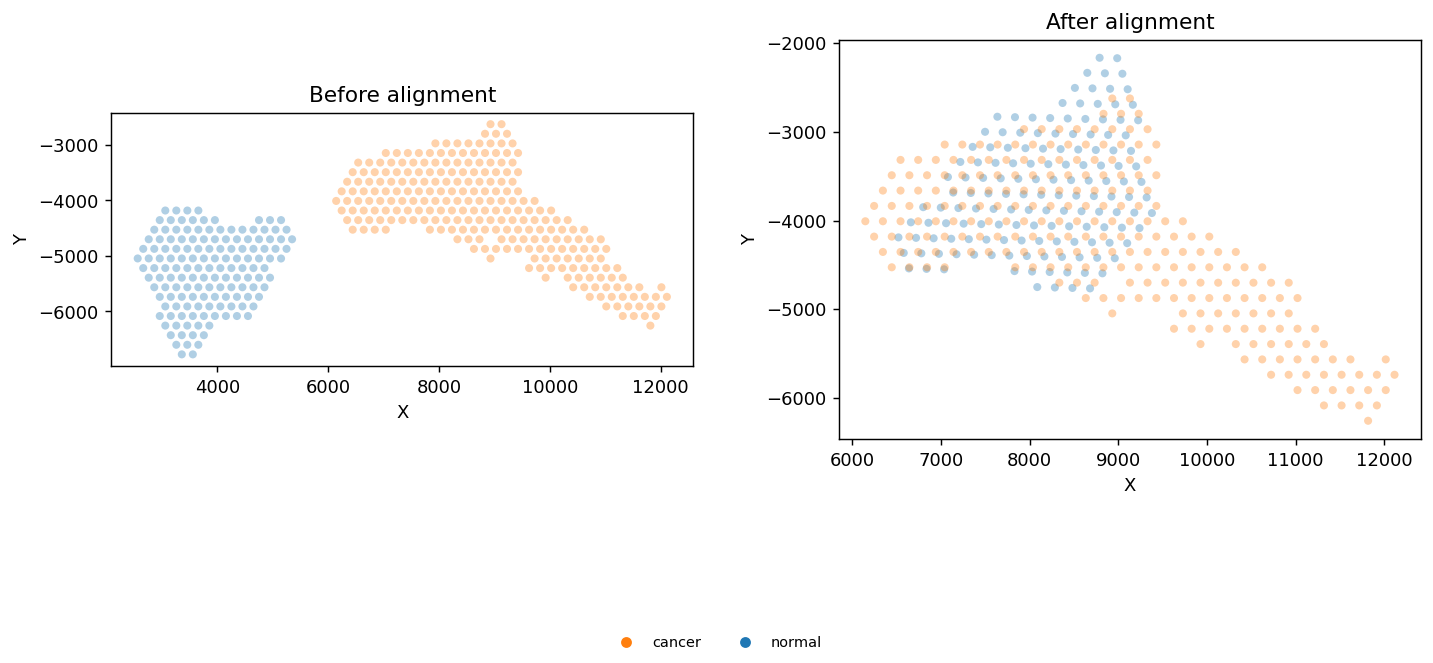

In [28]:
palette = annotation_palette(adata_upper_merged, 'cluster', EXPERIMENT_DIR / "colors.json")
sample_panels(adata_upper_merged, adata_upper_merged.obsm["spatial"][:, :2], 'status', 'cluster', palette, title="Before alignment", dimension=2, flip_y=True, size=20);
sample_panels(adata_upper_merged, adata_upper_merged.obs[["cx_aligned", "cy_aligned"]].to_numpy(), 'status', 'cluster', palette, title="After alignment", dimension=2, flip_y=True, size=20);
alignment_overlay(adata_upper_merged, adata_upper_merged.obsm["spatial"][:, :2], adata_upper_merged.obs[["cx_aligned", "cy_aligned"]].to_numpy(), 'status', 'cluster', palette, dimension=2, flip_y=True, size=20);
alignment_overlay(adata_upper_merged, adata_upper_merged.obsm["spatial"][:, :2], adata_upper_merged.obs[["cx_aligned", "cy_aligned"]].to_numpy(), 'status', 'cluster', palette, dimension=2, flip_y=True, size=20, by_sample=True);


In [29]:
adata_upper_merged


AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', '_scvi_batch', '_scvi_labels', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_scanVI'
    varm: 'PCs'
    layers: 'counts'

## Save input


In [30]:
model.save(model_dir, overwrite=True, save_anndata=True)
adata_upper_merged.write_h5ad(SCANVI_ADATA)
print(f"Saved model-ready AnnData: {SCANVI_ADATA}")


Saved model-ready AnnData: /home/zhouyj/stVirtual_tutorial/experiments/human_gastric_cancer/artifacts/checkpoints/scanvi/adata.h5ad
